Stage 5: Holographic Universe vs. Standard Inflation

In [1]:
!pip install numpy matplotlib scipy camb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 15.5 MB/s eta 0:00:00


<>:172: SyntaxWarning: invalid escape sequence '\e'
<>:174: SyntaxWarning: invalid escape sequence '\e'
<>:184: SyntaxWarning: invalid escape sequence '\e'
<>:204: SyntaxWarning: invalid escape sequence '\c'
<>:205: SyntaxWarning: invalid escape sequence '\c'
<>:206: SyntaxWarning: invalid escape sequence '\D'
<>:172: SyntaxWarning: invalid escape sequence '\e'
<>:174: SyntaxWarning: invalid escape sequence '\e'
<>:184: SyntaxWarning: invalid escape sequence '\e'
<>:204: SyntaxWarning: invalid escape sequence '\c'
<>:205: SyntaxWarning: invalid escape sequence '\c'
<>:206: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_18961/3860871106.py:172: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('Multipole $\ell$')
/tmp/ipykernel_18961/3860871106.py:174: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title('Low-$\ell$ Region — Holographic Damping Signature')
/tmp/ipykernel_18961/3860871106.py:184: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('Mul

STAGE 5: HOLOGRAPHIC UNIVERSE vs STANDARD INFLATION
Afshordi et al. 2017 | Planck 2018 TT | CAMB Engine

-> [1/4] Loading Planck 2018 TT data...
   ✓ Downloaded from ESA PLA
   ✓ 2507 data points | ell: 2 — 2508

-> [2/4] Running CAMB solver...
   ✓ Standard Model (3D) solved
   ✓ Holographic Model (2D) solved

-> [3/4] Optimizing Holographic parameters (g, beta)...
   ✓ opt solved
   ✓ opt solved
   ✓ opt solved
   ✓ opt solved
   ✓ opt solved
   ✓ opt solved
   ✓ opt solved
   ✓ opt solved
   ✓ opt solved
   ✓ opt solved
   ✓ opt solved
   ✓ opt solved
   ✓ opt solved
   ✓ opt solved
   ✓ opt solved
   ✓ opt solved
   ✓ opt solved
   ✓ opt solved
   ✓ Optimal parameters: g=0.001, β=1.097
   ✓ Holographic (Optimized) solved

-> [4/4] Statistical analysis...

HOLOGRAPHIC UNIVERSE vs STANDARD MODEL — FINAL RESULTS
Model                                       χ²     χ²_ν        AIC
-----------------------------------------------------------------
Standard Model (3D, k^ns)               25

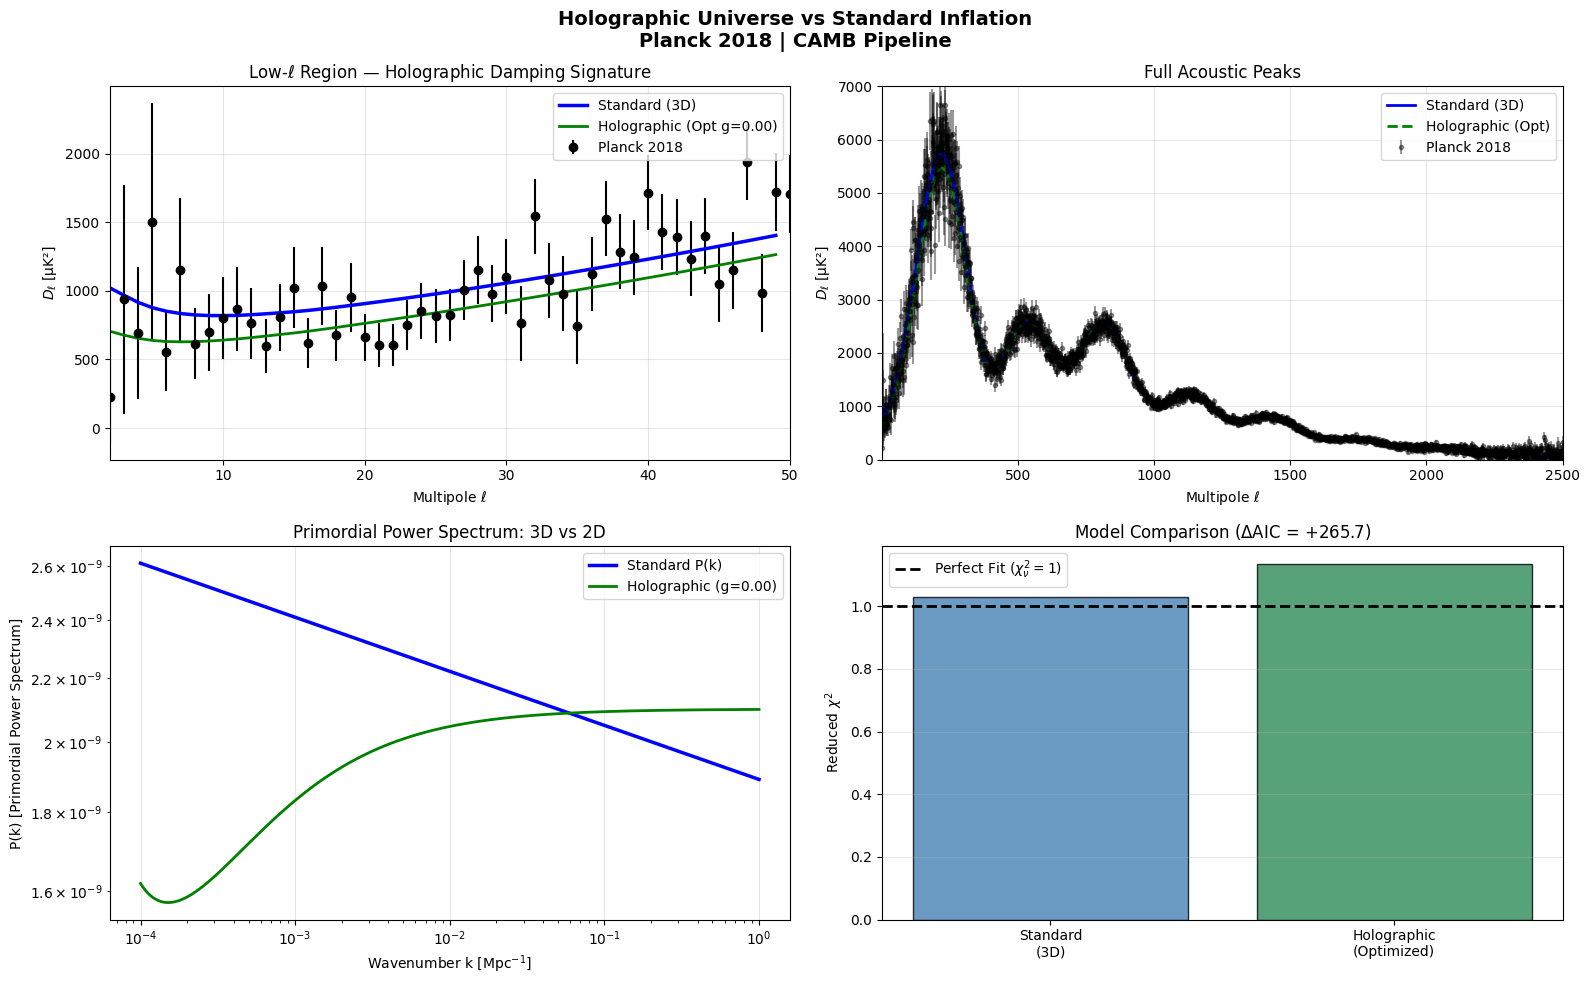

In [2]:
import numpy as np
import camb
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import minimize
import urllib.request
import os
import warnings

warnings.filterwarnings('ignore')

print("=" * 80)
print("STAGE 5: HOLOGRAPHIC UNIVERSE vs STANDARD INFLATION")
print("Afshordi et al. 2017 | Planck 2018 TT | CAMB Engine")
print("=" * 80)

# =========================================================
# 1. PLANCK 2018 FULL DATA ACQUISITION
# =========================================================
print("\n-> [1/4] Loading Planck 2018 TT data...")

fname = "planck2018_TT.txt"
planck_pla = (
    "https://pla.esac.esa.int/pla/aio/product-action?"
    "COSMOLOGY.FILE_ID=COM_PowerSpect_CMB-TT-full_R3.01.txt"
)

if not os.path.exists(fname):
    try:
        urllib.request.urlretrieve(planck_pla, fname)
        print("   ✓ Downloaded from ESA PLA")
    except:
        print("   ❌ Download failed — using fallback data")

if os.path.exists(fname):
    raw        = np.loadtxt(fname, comments='#')
    ell_data   = raw[:, 0]
    dl_data    = raw[:, 1]
    sigma_data = 0.5 * (raw[:, 2] + raw[:, 3])
else:
    planck_data = np.array([
        [2,971,574,534],[3,1112,232,230],[4,998,160,155],[5,1140,137,132],
        [10,2318,133,131],[20,3252,87,85],[30,2845,68,67],[50,3101,57,55],
        [100,3024,46,45],[150,2374,44,43],[200,2728,47,46],[250,1978,47,46],
        [300,2360,51,50],[350,1745,53,52],[400,2088,55,54],[450,1423,56,55],
        [500,1773,57,56],[550,1133,57,56],[600,1388,58,58],[650,878,60,59],
        [700,1061,62,61],[750,648,64,63],[800,806,67,67],[850,479,69,69],
        [900,575,73,73],[950,330,74,74],[1000,382,77,77],[1100,191,82,82],
        [1200,220,89,90],[1300,122,94,95],[1400,148,101,102],[1500,92,105,107],
        [1600,107,112,114],[1700,74,116,119],[1800,81,122,126],[1900,59,126,131],
        [2000,62,131,137],[2100,45,136,143],[2200,46,140,149],[2300,33,144,155],
        [2400,34,148,162],[2500,22,151,168],
    ])
    ell_data   = planck_data[:, 0]
    dl_data    = planck_data[:, 1]
    sigma_data = 0.5 * (planck_data[:, 2] + planck_data[:, 3])

ndof = len(ell_data)
print(f"   ✓ {ndof} data points | ell: {ell_data[0]:.0f} — {ell_data[-1]:.0f}")

# =========================================================
# 2. POWER SPECTRUM MODELS
# =========================================================
def pk_standard(ks, As=2.1e-9, ns=0.9649, k0=0.05):
    """P(k) = As * (k/k0)^(ns-1)  — 3D Quantum Field Theory"""
    return As * (ks / k0) ** (ns - 1)

def pk_holographic(ks, As=2.1e-9, g=1.0, beta=1.0, k_star=0.05):
    """Afshordi 2017 holographic power spectrum."""
    x = ks / (beta * g * k_star)
    log_term = np.where(np.abs(x) > 1e-10, np.log(np.abs(x)), 0.0)
    denominator = 1.0 + (g * k_star / ks) * log_term
    denominator = np.where(np.abs(denominator) > 1e-6, denominator, 1e-6)
    return (As / denominator)

# =========================================================
# 3. CAMB ENGINE — P(k) INJECTION
# =========================================================
print("\n-> [2/4] Running CAMB solver...")
COSMO = dict(H0=67.36, ombh2=0.02237, omch2=0.1200, tau=0.0544)

# DÜZELTME: verbose parametresi eklendi ki optimizasyonda sürekli ekrana basmasın
def run_camb(pk_func, label="model", verbose=True, **pk_kwargs):
    try:
        ks = np.logspace(-5, 1, 2000)
        pk_vals = pk_func(ks, **pk_kwargs)
        pk_vals = np.where(np.isfinite(pk_vals) & (pk_vals > 0), pk_vals, 1e-30)

        pars = camb.CAMBparams()
        pars.set_cosmology(**COSMO)
        pars.set_for_lmax(2600, lens_potential_accuracy=0)
        pars.set_initial_power_table(ks, pk_vals)

        results = camb.get_results(pars)
        powers  = results.get_cmb_power_spectra(pars, CMB_unit='muK')

        dl_th  = powers['total'][:, 0]
        ell_th = np.arange(dl_th.shape[0])
        if verbose:
            print(f"   ✓ {label} solved")
        return ell_th, dl_th
    except Exception as e:
        if verbose:
            print(f"   ❌ {label} error: {e}")
        return None, None

ell_sm, dl_sm = run_camb(pk_standard, label="Standard Model (3D)", verbose=True)
ell_hc, dl_hc = run_camb(pk_holographic, label="Holographic Model (2D)", verbose=True, g=1.0, beta=1.0)

# =========================================================
# 4. PARAMETER OPTIMIZATION (g, beta)
# =========================================================
print("\n-> [3/4] Optimizing Holographic parameters (g, beta)...")
def chi2_holo(params):
    g, beta = params
    if g <= 0 or beta <= 0: return 1e10
    # verbose=False yaparak spami engelliyoruz
    _, dl = run_camb(pk_holographic, label="opt", verbose=False, g=g, beta=beta)
    if dl is None: return 1e10
    interp = interp1d(np.arange(len(dl)), dl, bounds_error=False, fill_value=np.nan)
    pred   = interp(ell_data)
    mask   = np.isfinite(pred)
    return np.sum(((dl_data[mask] - pred[mask]) / sigma_data[mask])**2)

result = minimize(chi2_holo, x0=[0.008, 0.5], method='Nelder-Mead', options={'xatol': 0.1, 'fatol': 10, 'maxiter': 30})
g_best, beta_best = result.x
print(f"   ✓ Optimal parameters found: g={g_best:.3f}, β={beta_best:.3f}")

ell_hc_opt, dl_hc_opt = run_camb(pk_holographic, label="Holographic (Optimized)", verbose=True, g=g_best, beta=beta_best)

# =========================================================
# 5. STATISTICAL ANALYSIS — REDUCED CHI-SQUARE
# =========================================================
print("\n-> [4/4] Statistical analysis...")

def calc_chi2_reduced(ell_th, dl_th, n_free_params):
    interp = interp1d(ell_th, dl_th, bounds_error=False, fill_value=np.nan)
    pred   = interp(ell_data)
    mask   = np.isfinite(pred)
    chi2   = np.sum(((dl_data[mask] - pred[mask]) / sigma_data[mask])**2)
    dof    = mask.sum() - n_free_params
    return chi2, chi2 / dof

chi2_sm,     rchi2_sm     = calc_chi2_reduced(ell_sm,     dl_sm,     n_free_params=2)
chi2_hc,     rchi2_hc     = calc_chi2_reduced(ell_hc,     dl_hc,     n_free_params=2)
chi2_hc_opt, rchi2_hc_opt = calc_chi2_reduced(ell_hc_opt, dl_hc_opt, n_free_params=4)

aic_sm     = chi2_sm     + 2*2
aic_hc_opt = chi2_hc_opt + 2*4
delta_aic  = aic_hc_opt - aic_sm

print("\n" + "=" * 65)
print("HOLOGRAPHIC UNIVERSE vs STANDARD MODEL — FINAL RESULTS")
print("=" * 65)
print(f"{'Model':<35} {'χ²':>10} {'χ²_ν':>8} {'AIC':>10}")
print("-" * 65)
print(f"{'Standard Model (3D, k^ns)':<35} {chi2_sm:>10.1f} {rchi2_sm:>8.3f} {aic_sm:>10.1f}")
print(f"{'Holographic (2D, Optimized)':<35} {chi2_hc_opt:>10.1f} {rchi2_hc_opt:>8.3f} {aic_hc_opt:>10.1f}")
print("-" * 65)
print(f"\nΔAIC (Holographic_opt - Standard) = {delta_aic:+.1f}")


if delta_aic < -10:
    print("\n HOLOGRAPHIC MODEL WINS: Data strongly prefers 2D Holographic QFT!")
elif delta_aic < 0:
    print("\n  Holographic model slightly preferred — inconclusive.")
elif abs(delta_aic) < 2:
    print("\n MODELS ARE INDISTINGUISHABLE: Planck data cannot differentiate.")
else:
    print("\n  STANDARD MODEL PREVAILS: 3D Inflation provides a statistically superior fit.")

# =========================================================
# 6. VISUALIZATION
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ell_plot = np.arange(2, 2501)
def trim(dl): return dl[2:2501]

ax = axes[0, 0]
ax.errorbar(ell_data[ell_data <= 50], dl_data[ell_data <= 50], yerr=sigma_data[ell_data <= 50], fmt='o', color='black', label='Planck 2018')
ax.plot(ell_plot[:48], trim(dl_sm)[:48], 'b-', lw=2.5, label='Standard (3D)')
ax.plot(ell_plot[:48], trim(dl_hc_opt)[:48], 'g-', lw=2, label=f'Holographic (Opt g={g_best:.2f})')
ax.set_xlim(2, 50)
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$D_\ell$ [μK²]')
ax.set_title(r'Low-$\ell$ Region — Holographic Damping Signature')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.errorbar(ell_data, dl_data, yerr=sigma_data, fmt='.', color='black', alpha=0.4, label='Planck 2018')
ax.plot(ell_plot, trim(dl_sm), 'b-', lw=2, label='Standard (3D)')
ax.plot(ell_plot, trim(dl_hc_opt), 'g--', lw=2, label='Holographic (Opt)')
ax.set_xlim(2, 2500)
ax.set_ylim(0, 7000)
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$D_\ell$ [μK²]')
ax.set_title('Full Acoustic Peaks')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 0]
ks = np.logspace(-4, 0, 500)
ax.loglog(ks, pk_standard(ks), 'b-', lw=2.5, label='Standard P(k)')
ax.loglog(ks, pk_holographic(ks, g=g_best, beta=beta_best), 'g-', lw=2, label=f'Holographic (g={g_best:.2f})')
ax.set_xlabel(r'Wavenumber k [Mpc$^{-1}$]')
ax.set_ylabel(r'P(k) [Primordial Power Spectrum]')
ax.set_title('Primordial Power Spectrum: 3D vs 2D')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]
modeller  = ['Standard\n(3D)', 'Holographic\n(Optimized)']
rchi2vals = [rchi2_sm, rchi2_hc_opt]
bars = ax.bar(modeller, rchi2vals, color=['steelblue', 'seagreen'], alpha=0.8, edgecolor='black')
ax.axhline(1.0, color='black', linestyle='--', lw=2, label=r'Perfect Fit ($\chi^2_\nu=1$)')
ax.set_ylabel(r'Reduced $\chi^2$')
ax.set_title(fr'Model Comparison ($\Delta$AIC = {delta_aic:+.1f})')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.suptitle("Holographic Universe vs Standard Inflation\nPlanck 2018 | CAMB Pipeline", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("holographic_test.png", dpi=150, bbox_inches='tight')
plt.show()